# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030


# K-Means Image Compression (396 x 396 x 3)

Compress an image by quantizing its RGB colors down to K representative colors using K-Means.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030

from PIL import Image
import math


Image shape: (396, 396, 3)


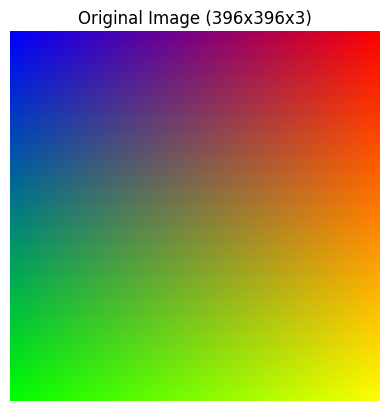

In [2]:
# ---- Option A: use your own image ----
# In Colab, upload with:
#   from google.colab import files
#   uploaded = files.upload()
#   img_path = list(uploaded.keys())[0]
#
# Then:
#   img = Image.open(img_path).convert("RGB").resize((396, 396))

# ---- Option B: generate a synthetic 396x396x3 demo image if none is provided ----
img_path = None  # <-- set this to your uploaded filename, e.g. "photo.jpg"

if img_path is not None:
    img = Image.open(img_path).convert("RGB").resize((396, 396))
else:
    size = 396
    x = np.linspace(0, 1, size)
    y = np.linspace(0, 1, size)
    xx, yy = np.meshgrid(x, y)
    r = (xx * 255).astype(np.uint8)
    g = (yy * 255).astype(np.uint8)
    b = (((1 - xx) * (1 - yy)) * 255).astype(np.uint8)
    arr = np.dstack([r, g, b])
    img = Image.fromarray(arr, "RGB")

img_array = np.array(img)
print("Image shape:", img_array.shape)
assert img_array.shape == (396, 396, 3), "Image must be 396 x 396 x 3"

plt.imshow(img_array)
plt.title("Original Image (396x396x3)")
plt.axis("off")
plt.show()


In [3]:
# Reshape image into a list of RGB pixels: (396*396, 3)
pixels = img_array.reshape(-1, 3).astype(np.float32)
print("Pixel matrix shape:", pixels.shape)

# Choose number of color clusters (K) -> this controls compression level
K = 16

kmeans_img = KMeans(n_clusters=K, n_init=10, random_state=42)
labels = kmeans_img.fit_predict(pixels)
palette = kmeans_img.cluster_centers_.astype(np.uint8)

# Rebuild the image using only the K palette colors
compressed_pixels = palette[labels]
compressed_img_array = compressed_pixels.reshape(396, 396, 3)


Pixel matrix shape: (156816, 3)


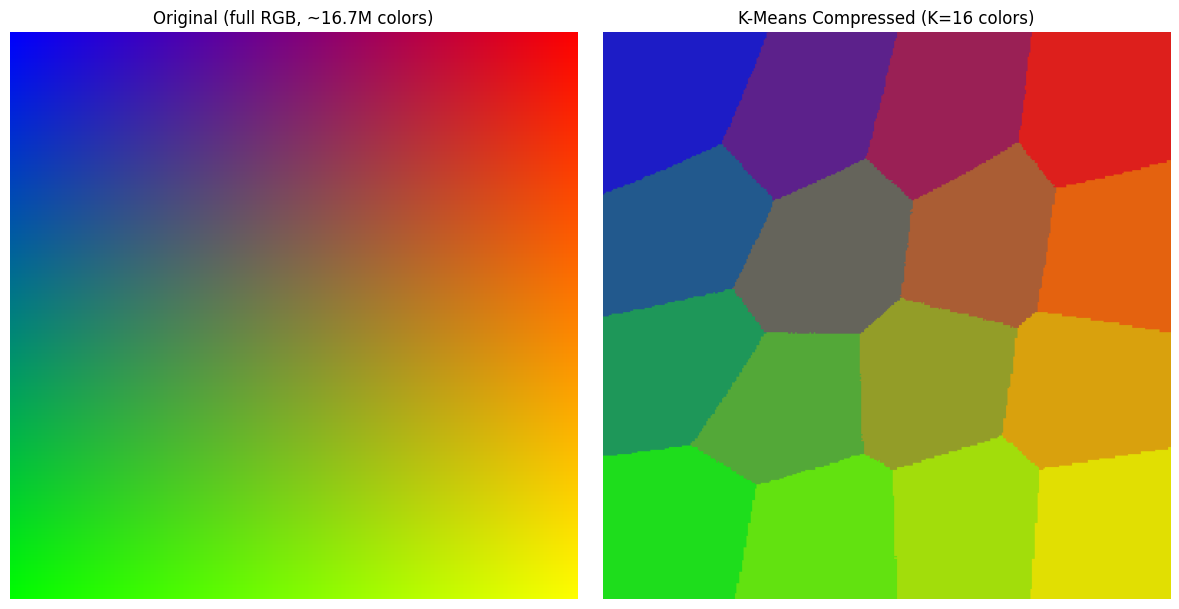

Saved compressed_image.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_array)
axes[0].set_title("Original (full RGB, ~16.7M colors)")
axes[0].axis("off")

axes[1].imshow(compressed_img_array)
axes[1].set_title(f"K-Means Compressed (K={K} colors)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

Image.fromarray(compressed_img_array).save("compressed_image.png")
print("Saved compressed_image.png")


In [5]:
# --- Compression ratio estimate ---
original_bytes = 396 * 396 * 3

bits_per_label = math.ceil(math.log2(K))
label_bytes = math.ceil(396 * 396 * bits_per_label / 8)
palette_bytes = K * 3

compressed_bytes = label_bytes + palette_bytes
ratio = original_bytes / compressed_bytes

print(f"Original size:     {original_bytes:,} bytes")
print(f"Compressed size:   {compressed_bytes:,} bytes (palette + {bits_per_label}-bit labels)")
print(f"Compression ratio: {ratio:.2f}x")


Original size:     470,448 bytes
Compressed size:   78,456 bytes (palette + 4-bit labels)
Compression ratio: 6.00x


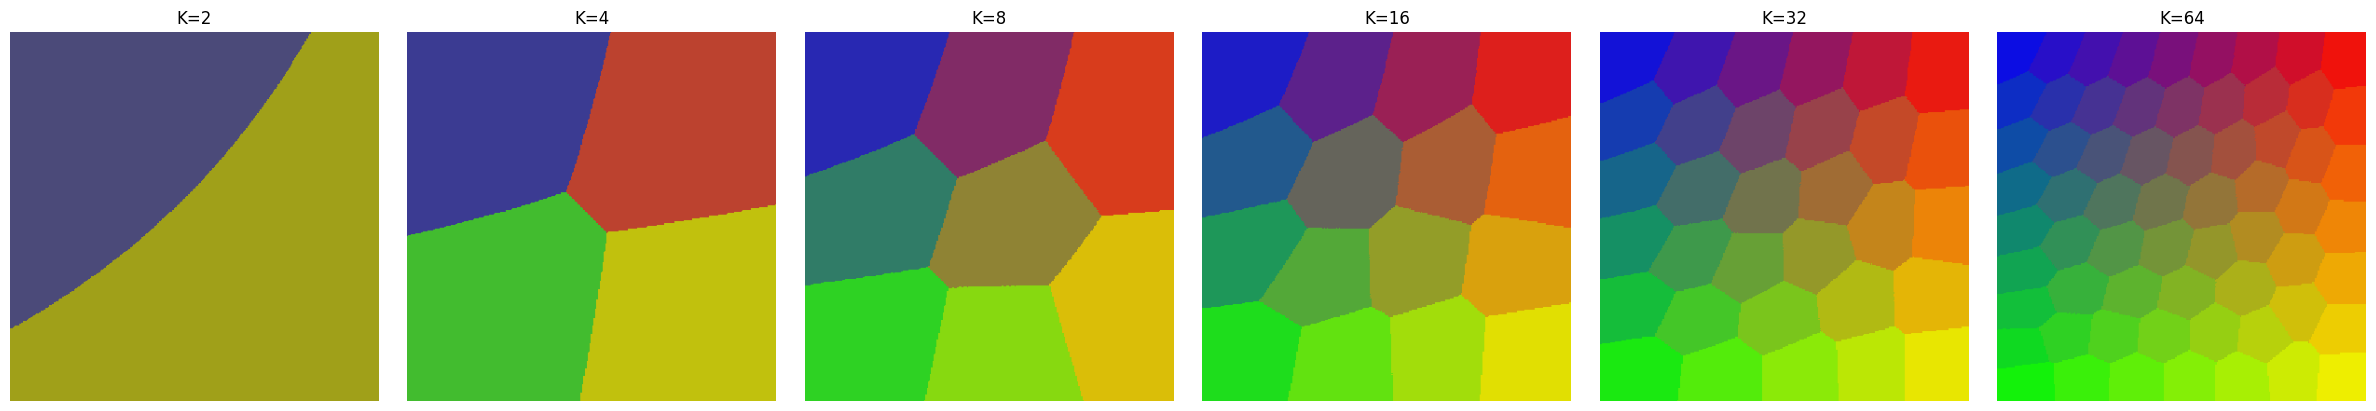

In [6]:
# --- Try multiple K values to see the quality/size tradeoff ---
K_values = [2, 4, 8, 16, 32, 64]
fig, axes = plt.subplots(1, len(K_values), figsize=(4*len(K_values), 4))

for ax, k in zip(axes, K_values):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    lbl = km.fit_predict(pixels)
    pal = km.cluster_centers_.astype(np.uint8)
    recon = pal[lbl].reshape(396, 396, 3)
    ax.imshow(recon)
    ax.set_title(f"K={k}")
    ax.axis("off")

plt.tight_layout()
plt.show()
